# Synthetic embedding visualizations

Visual diagnostics for the six RDF2Vec variants trained on the DLCC synthetic test cases (see `notebooks/synthetic_compare.ipynb` and `results.json`).

**Goal:** go beyond accuracy tables and show *why* some inits separate labels and others do not.

| method | what it reveals |
|---|---|
| **PCA** | directions of maximum variance — often *misses* the label boundary when signal lives in low-variance dimensions |
| **LDA** | the axis that best separates the two classes — matches what LogReg uses in 1-D |
| **t-SNE** | local neighbourhood structure (non-linear); useful to see collapsed class-mean inits |
| **norm / count plots** | whether cardinality signal survives as vector magnitude (tc09–tc12) |
| **structure-aware colouring** | whether geometry aligns with the *actual* graph feature defining each TC |

Walk corpora are reused from `notebooks/synthetic_compare/<tc>/`. Embeddings are re-trained on demand and cached under `notebooks/synthetic_visuals/cache/` so re-runs are fast.


In [5]:
"""Setup: paths, configuration, imports."""
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models.word2vec import LineSentence
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

ROOT = Path("..").resolve()
SCRIPTS = ROOT / "scripts"
COMPARE_ROOT = ROOT / "notebooks" / "synthetic_compare"
CACHE_ROOT = ROOT / "notebooks" / "synthetic_visuals" / "cache"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

sys.path.insert(0, str(ROOT / "scripts" / "plot"))
from _common import fit_lda_2d, LABEL_COLORS  # noqa: E402

from _evaluate import load_labeled_txt, tokens_to_embeddings  # noqa: E402
from _protograph_gen import iter_rdf_iris  # noqa: E402
from _synthetic_compare import (  # noqa: E402
    concept_bound_vectors,
    load_materialized_types,
    make_eval_fn,
    new_skipgram_model,
    normalized_stage1_vectors,
    pretrain_protograph,
    protograph_init,
    train_with_eval,
)

CFG = dict(
    dim=200,
    walks_per_entity=100,
    depth=3,
    epochs=5,
    pretrain_epochs=5,
    vanilla_alpha=0.025,
    finetune_alpha=0.0025,
    min_alpha=0.0001,
    target_norm=8.0,
    seed=42,
)

SHOWCASE_TCS = ["tc07", "tc09", "tc14"]
# existential restriction | cardinality | own-class membership
VARIANTS = [
    ("vanilla", dict(init="none", alpha=CFG["vanilla_alpha"], proto="p1")),
    ("p1_classic", dict(init="classic", alpha=CFG["vanilla_alpha"], proto="p1")),
    ("p3_bound", dict(init="bound", alpha=CFG["finetune_alpha"], proto="p3")),
]
VARIANT_COLORS = {
    "vanilla": "#9e9e9e",
    "p1_classic": "#c5b3e6",
    "p3_bound": "#0d47a1",
}

RESULTS = json.loads((COMPARE_ROOT / "results.json").read_text())

# Classic variants (*_classic) are finetuned at the from-scratch LR 0.025, not the protected 0.0025
# used by the *_bound variants. synthetic_compare/results.json keeps the 0.0025 classic rows (needed by
# synthetic_compare.ipynb); the 0.025 reruns live in cache/classic_025_results.json and are patched over
# the classic rows here so every section of THIS notebook is on one recipe.
_CLASSIC_025 = CACHE_ROOT / "classic_025_results.json"
if _CLASSIC_025.is_file():
    _c025 = json.loads(_CLASSIC_025.read_text())
    for _tc, _vmap in _c025.items():
        if _tc not in RESULTS:
            continue
        _rows = {r["variant"]: r for r in RESULTS[_tc]}
        for _v, _accs in _vmap.items():
            _rows.setdefault(_v, {"variant": _v, "tc": _tc})
            _rows[_v]["accs"] = _accs
            _rows[_v]["final_acc"] = _accs[-1]
        RESULTS[_tc] = list(_rows.values())


def tc_paths(tc: str) -> dict:
    tc_dir = ROOT / "v1" / "synthetic_ontology" / tc / "synthetic_ontology"
    return dict(
        ontology=tc_dir / "ontology.nt",
        graph=tc_dir / "graph.nt",
        train=tc_dir / "1000" / "train_test" / "train.txt",
        test=tc_dir / "1000" / "train_test" / "test.txt",
        config=tc_dir / "configuration.txt",
        out=COMPARE_ROOT / tc,
    )


def load_tc_config(config_path: Path) -> dict:
    out = {}
    for line in config_path.read_text(encoding="utf-8").splitlines():
        if line.startswith("Target property:"):
            out["target_prop"] = line.split(":", 1)[1].strip().strip("<>")
        elif line.startswith("Positive object class:"):
            out["pos_class"] = line.split(":", 1)[1].strip().strip("<>")
        elif line.startswith("Negative object class:"):
            out["neg_class"] = line.split(":", 1)[1].strip().strip("<>")
    return out


for tc in SHOWCASE_TCS:
    for k, p in tc_paths(tc).items():
        if k != "out":
            assert p.is_file(), f"Missing {k} for {tc}: {p}"

print("Cache:", CACHE_ROOT)
print("Showcase TCs:", ", ".join(SHOWCASE_TCS))


Cache: /home/bnukhkadiev/Knowledge-Graphs/notebooks/synthetic_visuals/cache
Showcase TCs: tc07, tc09, tc14


In [6]:
"""Train or load cached test-entity embeddings (epoch 0 and epoch 5)."""

_stage1_cache: dict[tuple[str, str], tuple] = {}


def _stage1(proto_walks: Path) -> tuple:
    key = (str(proto_walks), str(CFG["target_norm"]))
    if key not in _stage1_cache:
        pre = pretrain_protograph(
            proto_walks, dim=CFG["dim"], epochs=CFG["pretrain_epochs"], seed=CFG["seed"]
        )
        _stage1_cache[key] = normalized_stage1_vectors(pre.wv, target_norm=CFG["target_norm"])
    return _stage1_cache[key]


def snapshot_variant(tc: str, variant: str, *, init: str, alpha: float, proto: str) -> dict:
    sp = tc_paths(tc)
    inst_walks = sp["out"] / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt"
    proto_walks = sp["out"] / f"walks_{proto}.txt"
    if not inst_walks.is_file() or not proto_walks.is_file():
        raise FileNotFoundError(f"Missing walks for {tc}; run synthetic_compare first")

    model = new_skipgram_model(
        dim=CFG["dim"], alpha=alpha, min_alpha=CFG["min_alpha"], seed=CFG["seed"], workers=16
    )
    model.build_vocab(LineSentence(str(inst_walks)))
    if init != "none":
        stage1, used_norm = _stage1(proto_walks)
        bound = None
        if init == "bound":
            bound = concept_bound_vectors(sp["graph"], sp["ontology"], stage1, target_norm=used_norm)
        protograph_init(
            model, stage1, sp["ontology"], strategy="all_init",
            target_norm=used_norm, bound_vectors=bound,
        )

    test_tokens, y_test = load_labeled_txt(sp["test"])
    emb = np.asarray(model.wv.vectors, dtype=np.float32)
    w2i = dict(model.wv.key_to_index)
    x0, _oov0 = tokens_to_embeddings(test_tokens, emb, w2i, "", 4096, progress=False)

    accs = train_with_eval(
        model, inst_walks, epochs=CFG["epochs"], alpha=alpha, min_alpha=CFG["min_alpha"],
        eval_fn=make_eval_fn(sp["train"], sp["test"]),
    )
    emb5 = np.asarray(model.wv.vectors, dtype=np.float32)
    x5, _oov5 = tokens_to_embeddings(test_tokens, emb5, w2i, "", 4096, progress=False)

    n0, n5 = np.linalg.norm(x0, axis=1), np.linalg.norm(x5, axis=1)
    ok = (n0 > 0) & (n5 > 0)
    mean_cos = float(((x0[ok] * x5[ok]).sum(1) / (n0[ok] * n5[ok])).mean()) if ok.any() else float("nan")
    n_distinct = int(np.unique(np.round(x0, 5), axis=0).shape[0])

    return dict(
        variant=variant, x0=x0, x5=x5, y=y_test, accs=accs,
        mean_cos=mean_cos, n_distinct=n_distinct, n_test=len(y_test),
    )


def load_or_train_tc(tc: str, *, force: bool = False) -> dict[str, dict]:
    cache_path = CACHE_ROOT / f"{tc}.npz"
    if cache_path.is_file() and not force:
        data = np.load(cache_path, allow_pickle=True)
        runs = {}
        for variant, _ in VARIANTS:
            runs[variant] = dict(
                variant=variant,
                x0=data[f"{variant}_x0"],
                x5=data[f"{variant}_x5"],
                y=data["y_test"],
                accs=list(data[f"{variant}_accs"]),
                mean_cos=float(data[f"{variant}_mean_cos"]),
                n_distinct=int(data[f"{variant}_n_distinct"]),
                n_test=int(data["n_test"]),
            )
        print(f"{tc}: loaded cache ({cache_path.name})")
        return runs

    t0 = time.time()
    runs = {}
    save = {"y_test": None, "n_test": 0}
    for variant, opts in VARIANTS:
        print(f"  training {tc} / {variant} ...", flush=True)
        runs[variant] = snapshot_variant(tc, variant, **opts)
        r = runs[variant]
        save["y_test"] = r["y"]
        save["n_test"] = r["n_test"]
        save[f"{variant}_x0"] = r["x0"]
        save[f"{variant}_x5"] = r["x5"]
        save[f"{variant}_accs"] = np.asarray(r["accs"])
        save[f"{variant}_mean_cos"] = r["mean_cos"]
        save[f"{variant}_n_distinct"] = r["n_distinct"]
    np.savez_compressed(cache_path, **save)
    print(f"{tc}: trained + cached in {time.time() - t0:.1f}s")
    return runs


EMB = {tc: load_or_train_tc(tc) for tc in SHOWCASE_TCS}


tc07: loaded cache (tc07.npz)
tc09: loaded cache (tc09.npz)
tc14: loaded cache (tc14.npz)


## 1. PCA vs LDA — variance vs separability

On tc07 the label is "has `P_19` edge to a `C_390` instance" (not the entity's own class). **PCA** projects onto maximum-variance directions; the discriminative axis for `p3_bound` often has *low* variance, so the two classes look mixed. **LDA** (LD1 + an orthogonal PC for layout) projects onto the direction LogReg exploits — separation appears immediately at epoch 0.


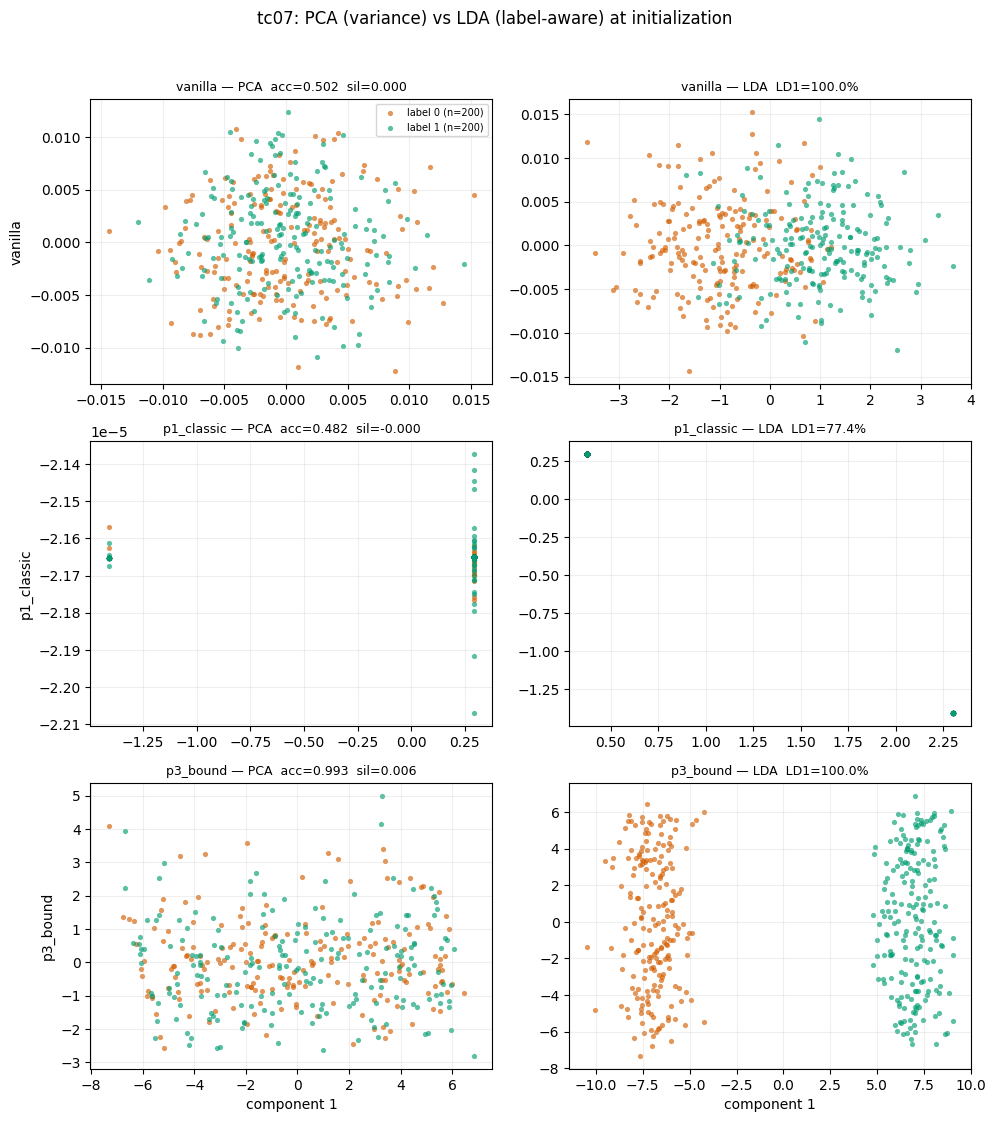

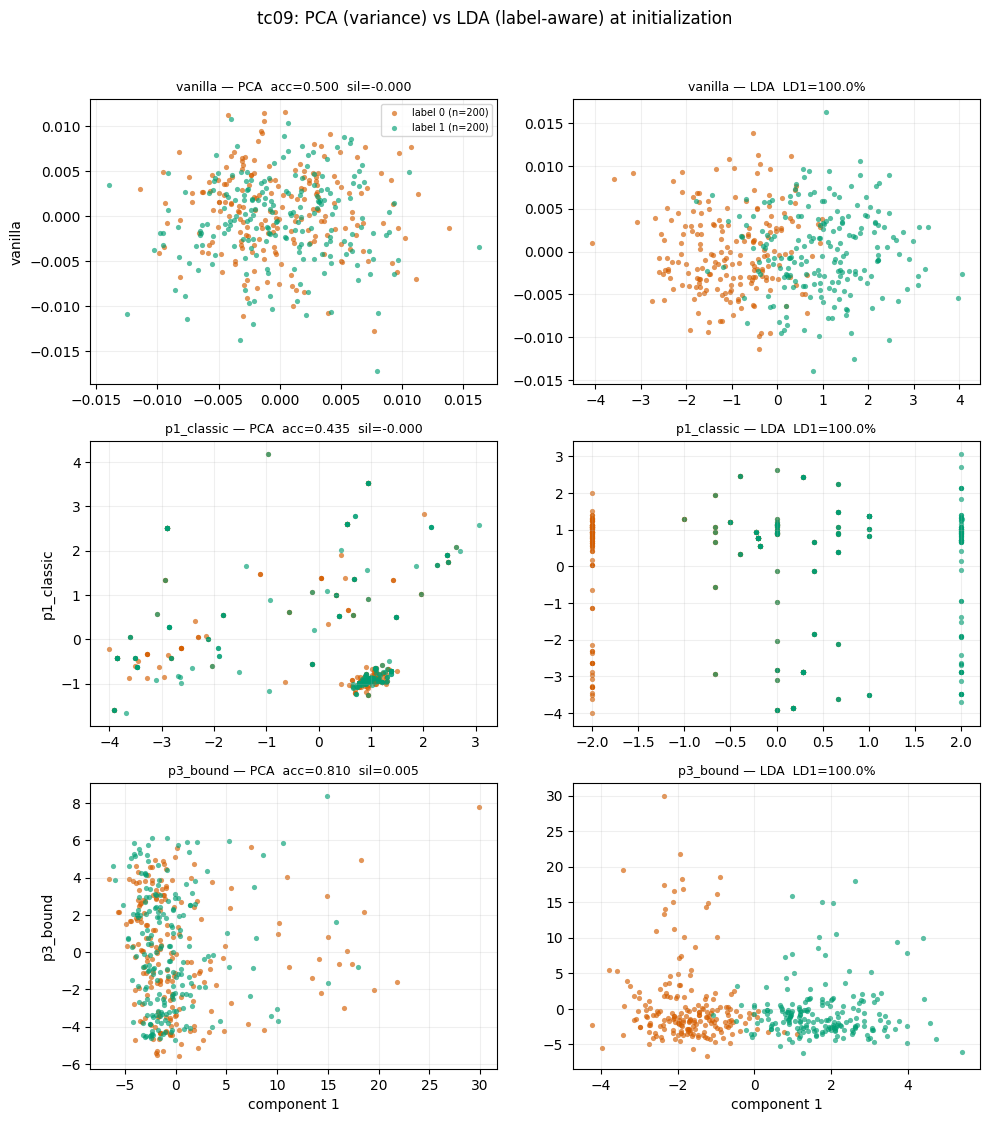

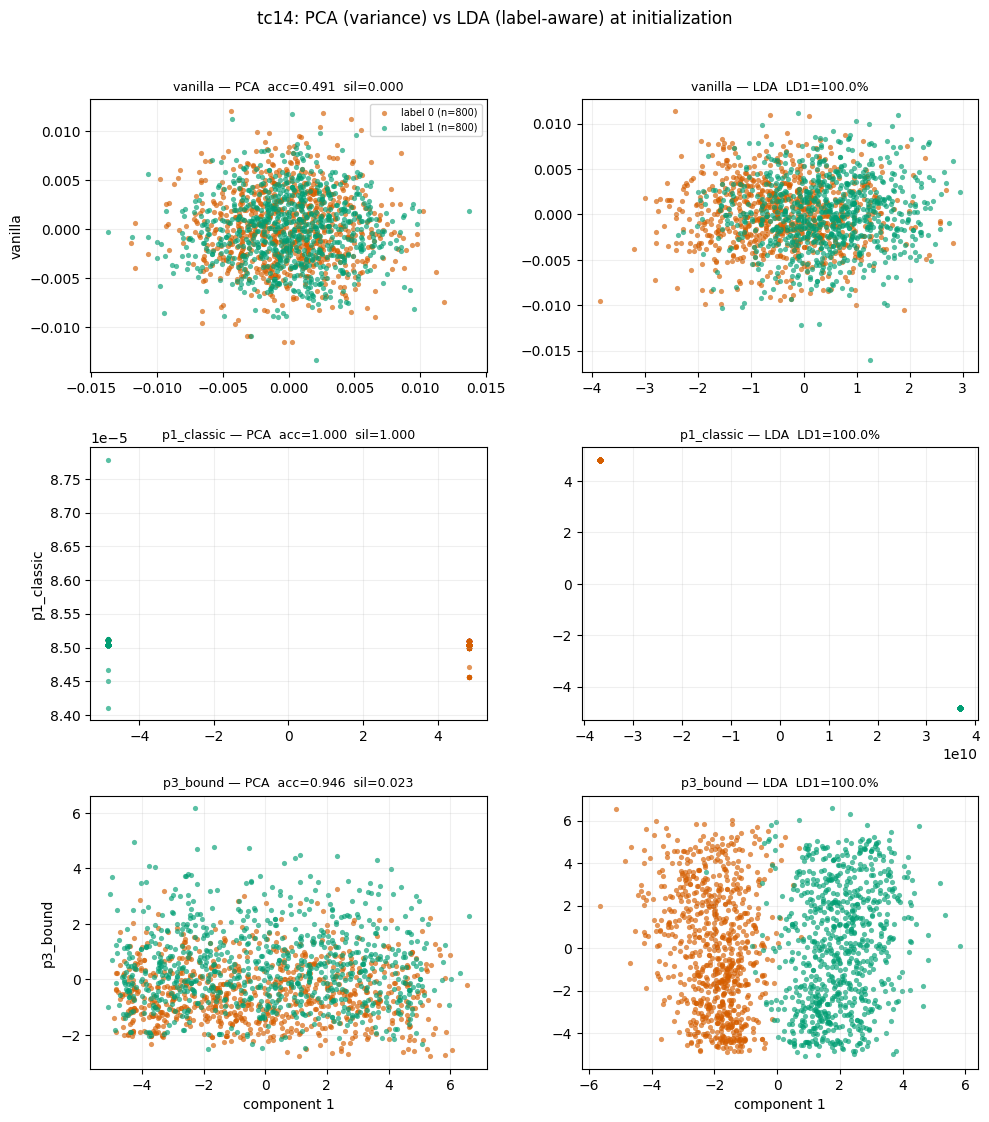

In [7]:
def scatter_labels(ax, xy, y, *, title: str, alpha=0.65, s=14):
    for lab in (0, 1):
        m = y == lab
        ax.scatter(
            xy[m, 0], xy[m, 1], s=s, alpha=alpha, color=LABEL_COLORS[lab],
            label=f"label {lab} (n={int(m.sum())})", lw=0,
        )
    ax.set_title(title, fontsize=9)
    ax.grid(True, alpha=0.2)


def plot_pca_lda_row(tc: str, variant: str, run: dict):
    x, y = run["x0"], run["y"]
    acc = run["accs"][0]
    sil = silhouette_score(x, y) if len(np.unique(y)) > 1 else float("nan")

    pca = PCA(n_components=2, random_state=CFG["seed"])
    xy_pca = pca.fit_transform(x)
    xy_lda, ld1, orth = fit_lda_2d(x, y, seed=CFG["seed"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    scatter_labels(
        axes[0], xy_pca, y,
        title=f"PCA — acc@init {acc:.3f}, sil={sil:.3f}\n"
              f"PC1 {pca.explained_variance_ratio_[0]*100:.1f}%, PC2 {pca.explained_variance_ratio_[1]*100:.1f}%",
    )
    scatter_labels(
        axes[1], xy_lda, y,
        title=f"LDA — LD1 {ld1*100:.1f}%, PC⊥ {orth*100:.1f}%",
    )
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[1].set_xlabel("LD1")
    axes[1].set_ylabel("PC⊥")
    for ax in axes:
        ax.legend(fontsize=7, loc="best")
    fig.suptitle(f"{tc} / {variant} — test entities at epoch 0", fontsize=11)
    fig.tight_layout()
    return fig


for tc in SHOWCASE_TCS:
    fig, axes = plt.subplots(len(VARIANTS), 2, figsize=(10, 3.8 * len(VARIANTS)))
    if len(VARIANTS) == 1:
        axes = np.array([axes])
    for row, (variant, _) in enumerate(VARIANTS):
        run = EMB[tc][variant]
        x, y = run["x0"], run["y"]
        acc = run["accs"][0]
        sil = silhouette_score(x, y)
        pca = PCA(n_components=2, random_state=CFG["seed"])
        xy_pca = pca.fit_transform(x)
        xy_lda, ld1, orth = fit_lda_2d(x, y, seed=CFG["seed"])
        scatter_labels(
            axes[row, 0], xy_pca, y,
            title=f"{variant} — PCA  acc={acc:.3f}  sil={sil:.3f}",
        )
        scatter_labels(
            axes[row, 1], xy_lda, y,
            title=f"{variant} — LDA  LD1={ld1*100:.1f}%",
        )
        axes[row, 0].set_ylabel(variant)
    for ax in axes[-1]:
        ax.set_xlabel("component 1")
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(f"{tc}: PCA (variance) vs LDA (label-aware) at initialization", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


## 2. Finetune drift — epoch 0 → epoch 5 arrows (PCA)

Shared PCA basis per variant (fit on epoch-0 ∪ epoch-5). Short arrows mean the protected LR (`0.0025`) barely moves embeddings — desirable for `p3_bound` (preserves init features), problematic for `p1_classic` when the init is already uninformative.


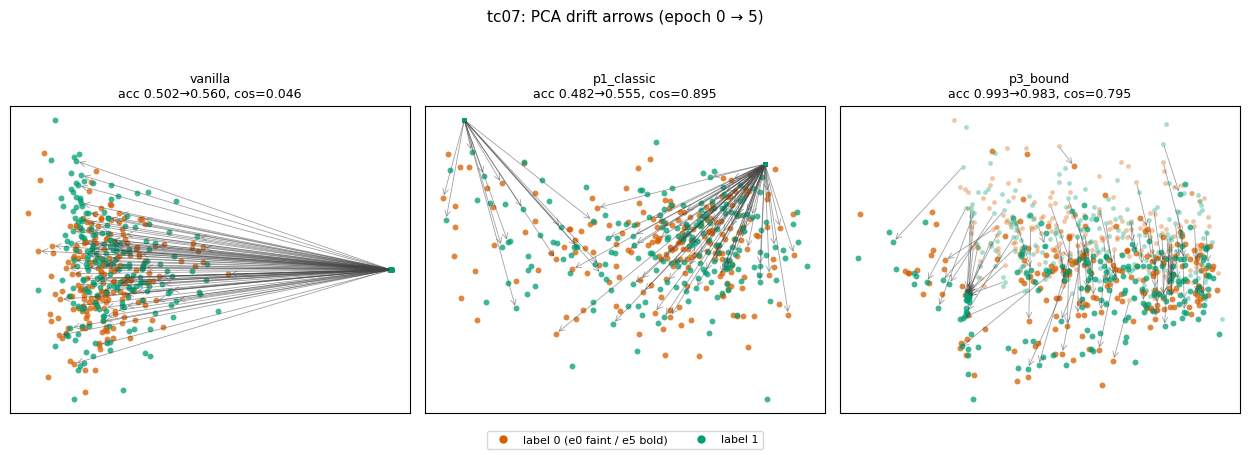

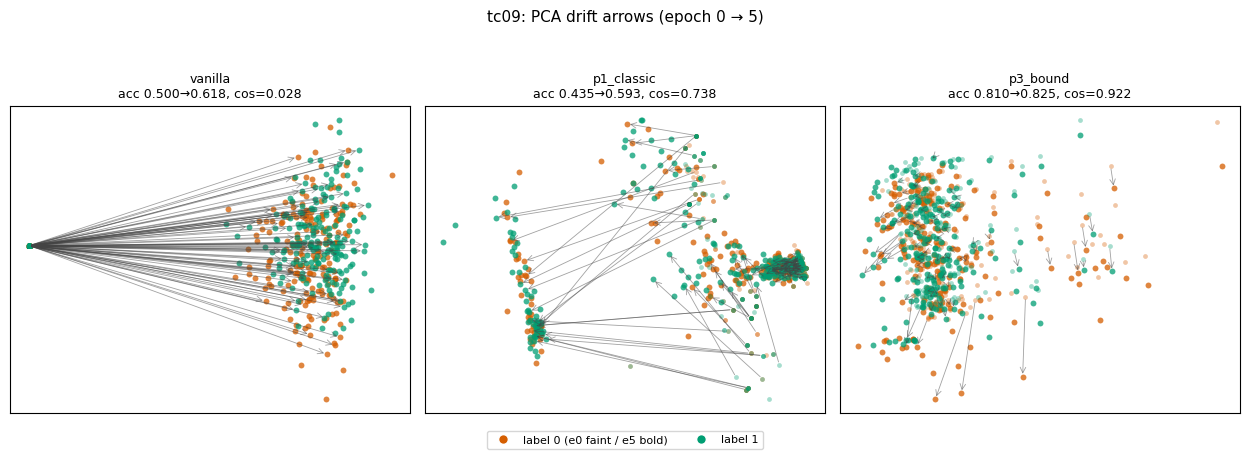

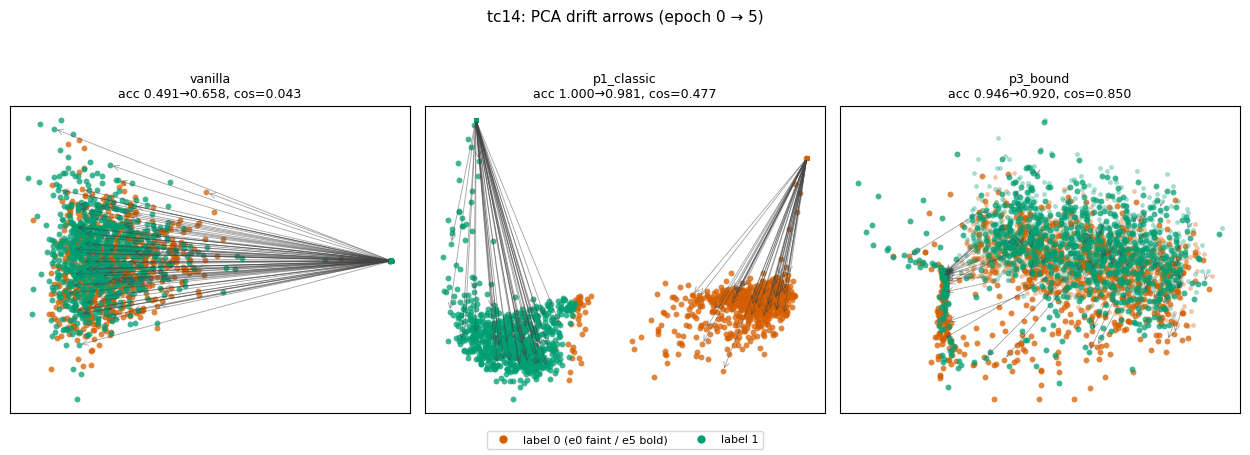

In [47]:
def plot_drift_arrows(tc: str):
    runs = EMB[tc]
    y = next(iter(runs.values()))["y"]
    fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.2 * len(VARIANTS), 4.5), sharex=False, sharey=False)
    if len(VARIANTS) == 1:
        axes = [axes]

    for ax, (variant, _) in zip(axes, VARIANTS):
        run = runs[variant]
        x0, x5 = run["x0"], run["x5"]
        xy = PCA(n_components=2, random_state=CFG["seed"]).fit_transform(np.vstack([x0, x5]))
        xy0, xy5 = xy[: len(x0)], xy[len(x0):]
        for lab, color in LABEL_COLORS.items():
            m = y == lab
            ax.scatter(xy0[m, 0], xy0[m, 1], s=12, alpha=0.35, color=color, lw=0)
            ax.scatter(xy5[m, 0], xy5[m, 1], s=18, alpha=0.75, color=color, lw=0)
        step = max(1, len(xy0) // 80)
        for i in range(0, len(xy0), step):
            ax.annotate(
                "", xy=(xy5[i, 0], xy5[i, 1]), xytext=(xy0[i, 0], xy0[i, 1]),
                arrowprops=dict(arrowstyle="->", color="#444444", lw=0.6, alpha=0.5),
            )
        ax.set_title(
            f"{variant}\nacc {run['accs'][0]:.3f}→{run['accs'][-1]:.3f}, cos={run['mean_cos']:.3f}",
            fontsize=9,
        )
        ax.set_xticks([])
        ax.set_yticks([])
    handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=LABEL_COLORS[0], markersize=7, label="label 0 (e0 faint / e5 bold)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=LABEL_COLORS[1], markersize=7, label="label 1"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=8)
    fig.suptitle(f"{tc}: PCA drift arrows (epoch 0 → 5)", fontsize=11)
    fig.tight_layout(rect=(0, 0.05, 1, 0.94))
    plt.show()


for tc in SHOWCASE_TCS:
    plot_drift_arrows(tc)


## 3. Cardinality signal — embedding norm vs edge count (tc09)

tc09 labels entities with **one** vs **two** outgoing `P_1339` edges. Concept-bound init *accumulates* bound features, so positives should have **larger** L2 norms. Per-vector renormalization would erase this — the global rescale in `p3_bound` preserves it.


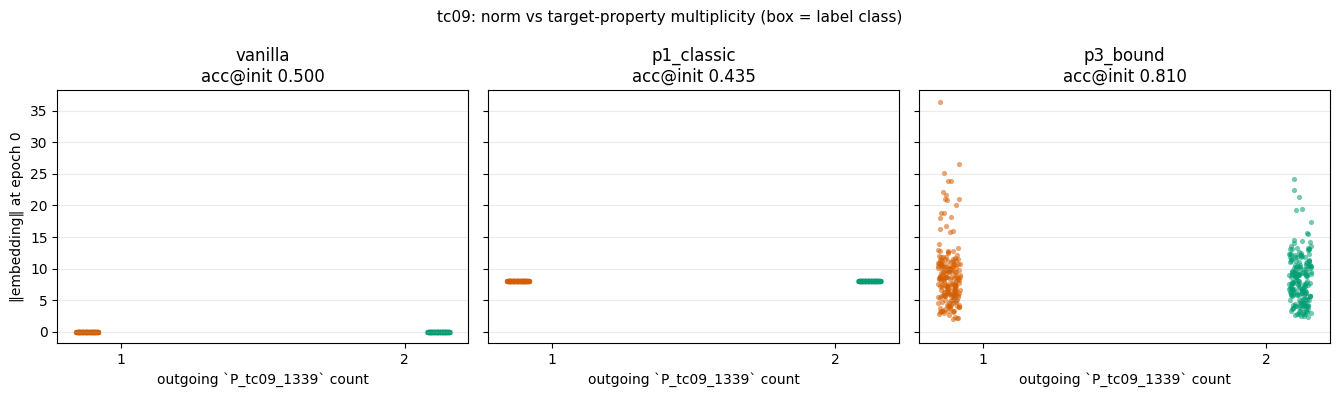

In [48]:
def edge_counts(graph_nt: Path, target_prop: str) -> dict[str, int]:
    counts: dict[str, int] = {}
    for s, p, o in iter_rdf_iris(graph_nt):
        if p == target_prop:
            counts[s] = counts.get(s, 0) + 1
    return counts


def plot_norm_vs_count(tc: str = "tc09"):
    sp = tc_paths(tc)
    cfg = load_tc_config(sp["config"])
    target_prop = cfg["target_prop"]
    counts = edge_counts(sp["graph"], target_prop)

    test_tokens, y_test = load_labeled_txt(sp["test"])
    count_arr = np.array([counts.get(t.strip("<>"), 0) for t in test_tokens])

    fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.5 * len(VARIANTS), 4), sharey=True)
    if len(VARIANTS) == 1:
        axes = [axes]

    offsets = {0: -0.12, 1: 0.12}
    for ax, (variant, _) in zip(axes, VARIANTS):
        run = EMB[tc][variant]
        norms = np.linalg.norm(run["x0"], axis=1)
        for lab in (0, 1):
            m = y_test == lab
            jitter = np.random.default_rng(CFG["seed"]).uniform(-0.04, 0.04, size=int(m.sum()))
            ax.scatter(
                count_arr[m] + offsets[lab] + jitter, norms[m], s=14, alpha=0.55,
                color=LABEL_COLORS[lab], label=f"label {lab}", lw=0,
            )
        ax.set_xticks(sorted(set(count_arr)))
        ax.set_xlabel(f"outgoing `{target_prop}` count")
        ax.set_title(f"{variant}\nacc@init {run['accs'][0]:.3f}")
        ax.grid(True, axis="y", alpha=0.25)
    axes[0].set_ylabel("‖embedding‖ at epoch 0")
    fig.suptitle(f"{tc}: norm vs target-property multiplicity (box = label class)", fontsize=11)
    fig.tight_layout()
    plt.show()


plot_norm_vs_count("tc09")


## 4. t-SNE — local cluster structure at initialization

t-SNE stresses *local* neighbourhoods. `p1_classic` collapses entities onto ~few hundred class-mean points (visible as tight blobs); `p3_bound` spreads instances while keeping label-consistent micro-clusters.


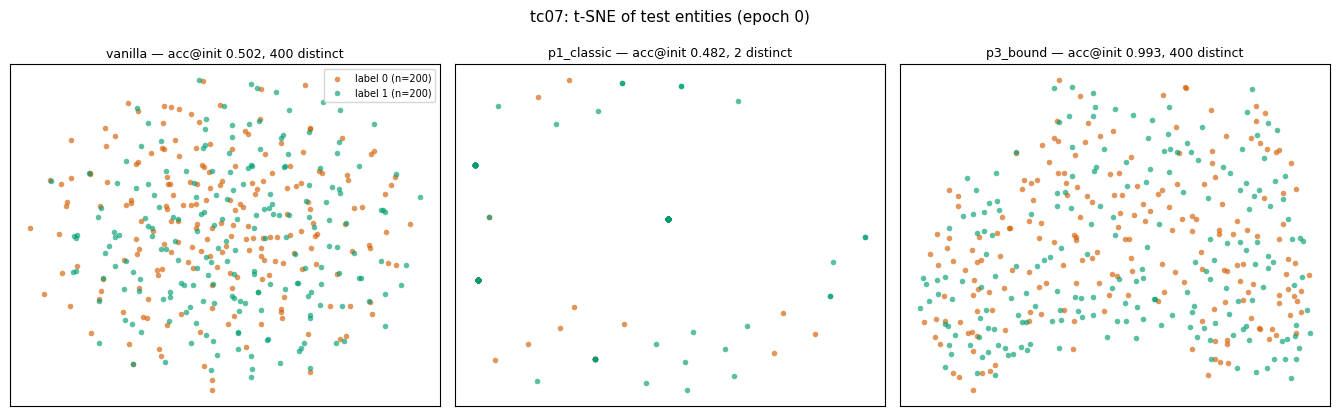

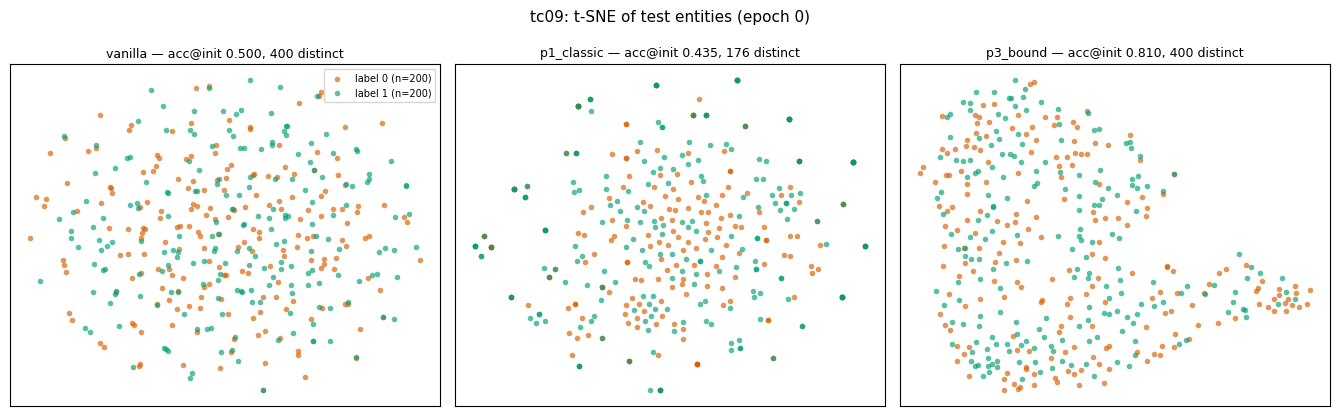

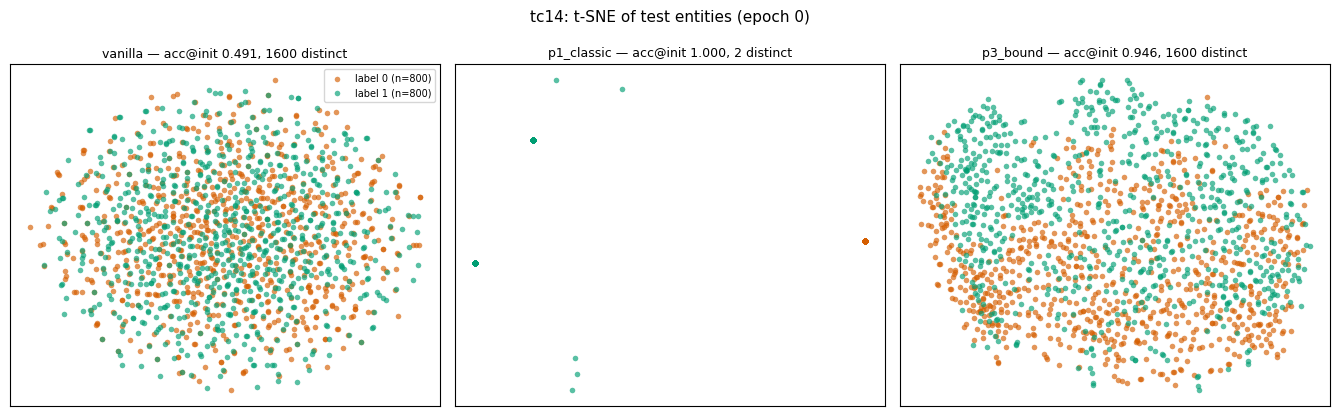

In [49]:
def plot_tsne_panel(tc: str):
    runs = EMB[tc]
    y = next(iter(runs.values()))["y"]
    fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.5 * len(VARIANTS), 4.2))
    if len(VARIANTS) == 1:
        axes = [axes]

    for ax, (variant, _) in zip(axes, VARIANTS):
        run = runs[variant]
        x = run["x0"]
        xy = TSNE(n_components=2, perplexity=35, learning_rate="auto", init="pca", random_state=CFG["seed"]).fit_transform(x)
        scatter_labels(ax, xy, y, title=f"{variant} — acc@init {run['accs'][0]:.3f}, {run['n_distinct']} distinct", s=16)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0].legend(fontsize=7)
    fig.suptitle(f"{tc}: t-SNE of test entities (epoch 0)", fontsize=11)
    fig.tight_layout()
    plt.show()


for tc in SHOWCASE_TCS:
    plot_tsne_panel(tc)


## 5. Structure-aware colouring — does geometry match the graph feature?

**tc07:** colour by the materialized class of the `P_19` neighbour (positive class `C_390` vs negative `C_281`). A good embedding should separate *pos-neighbour* from *neg-neighbour* even before labels are shown.

**tc14:** everyone shares structural features; here labels follow *own class* membership — `p1_classic` should align with structure while `vanilla` stays mixed.


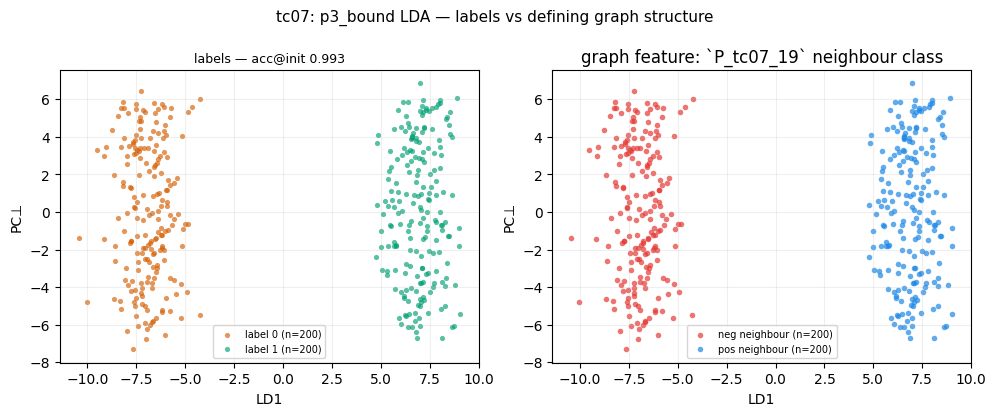

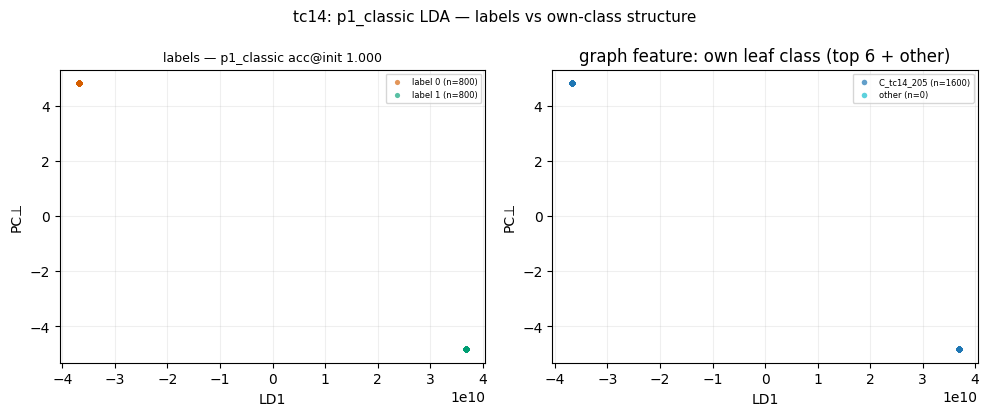

In [50]:
def neighbor_buckets(graph_nt: Path, types: dict, target_prop: str, pos_class: str, neg_class: str) -> dict[str, str]:
    """Map entity IRI -> bucket from target-property neighbour materialized classes."""
    flags: dict[str, tuple[bool, bool]] = {}
    for s, p, o in iter_rdf_iris(graph_nt):
        if p != target_prop:
            continue
        has_pos = has_neg = False
        for c in types.get(o, ()):
            if c == pos_class:
                has_pos = True
            if c == neg_class:
                has_neg = True
        prev = flags.get(s, (False, False))
        flags[s] = (prev[0] or has_pos, prev[1] or has_neg)
    out = {}
    for ent, (has_pos, has_neg) in flags.items():
        if has_pos and not has_neg:
            out[ent] = "pos neighbour"
        elif has_neg and not has_pos:
            out[ent] = "neg neighbour"
        else:
            out[ent] = "mixed / other"
    return out


STRUCT_COLORS = {
    "pos neighbour": "#1e88e5",
    "neg neighbour": "#e53935",
    "mixed / other": "#9e9e9e",
}


def plot_structure_colored_lda(tc: str):
    sp = tc_paths(tc)
    cfg = load_tc_config(sp["config"])
    if "pos_class" not in cfg:
        print(f"{tc}: no pos/neg neighbour classes in configuration — skip structure plot")
        return

    types = load_materialized_types(sp["ontology"])
    test_tokens, y_test = load_labeled_txt(sp["test"])
    bucket_map = neighbor_buckets(sp["graph"], types, cfg["target_prop"], cfg["pos_class"], cfg["neg_class"])
    buckets = np.array([bucket_map.get(t.strip("<>"), "mixed / other") for t in test_tokens])

    run = EMB[tc]["p3_bound"]
    xy, ld1, orth = fit_lda_2d(run["x0"], run["y"], seed=CFG["seed"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    scatter_labels(axes[0], xy, y_test, title=f"labels — acc@init {run['accs'][0]:.3f}")
    for bkt in sorted(set(buckets)):
        m = buckets == bkt
        axes[1].scatter(
            xy[m, 0], xy[m, 1], s=16, alpha=0.7, color=STRUCT_COLORS.get(bkt, "#666"),
            label=f"{bkt} (n={int(m.sum())})", lw=0,
        )
    axes[1].set_title(f"graph feature: `{cfg['target_prop']}` neighbour class")
    for ax in axes:
        ax.set_xlabel("LD1")
        ax.set_ylabel("PC⊥")
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=7)
    fig.suptitle(f"{tc}: p3_bound LDA — labels vs defining graph structure", fontsize=11)
    fig.tight_layout()
    plt.show()


plot_structure_colored_lda("tc07")


# tc14: colour by asserted leaf class (the feature classic MASCHInE encodes)
sp14 = tc_paths("tc14")
types14 = load_materialized_types(sp14["ontology"])
test_tokens14, y14 = load_labeled_txt(sp14["test"])
leaf_class = np.array([types14.get(t.strip("<>"), ["?"])[0] for t in test_tokens14])
top_classes = pd.Series(leaf_class).value_counts().head(6).index.tolist()
leaf_bucket = np.array([c if c in top_classes else "other" for c in leaf_class])

run14 = EMB["tc14"]["p1_classic"]
xy14, _, _ = fit_lda_2d(run14["x0"], run14["y"], seed=CFG["seed"])
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
scatter_labels(axes[0], xy14, y14, title=f"labels — p1_classic acc@init {run14['accs'][0]:.3f}")
cmap = plt.colormaps["tab10"].resampled(len(top_classes) + 1)
for i, cls in enumerate(top_classes + ["other"]):
    m = leaf_bucket == cls
    axes[1].scatter(xy14[m, 0], xy14[m, 1], s=16, alpha=0.7, color=cmap(i), label=f"{cls} (n={int(m.sum())})", lw=0)
axes[1].set_title("graph feature: own leaf class (top 6 + other)")
for ax in axes:
    ax.set_xlabel("LD1"); ax.set_ylabel("PC⊥"); ax.grid(True, alpha=0.2); ax.legend(fontsize=6)
fig.suptitle("tc14: p1_classic LDA — labels vs own-class structure", fontsize=11)
fig.tight_layout()
plt.show()


## 6. Separability dashboard — silhouette, distinct vectors, drift

Quantitative summary across showcase TCs. **Silhouette** measures blob-like cluster separation (Euclidean); linearly separable but elongated clouds can score ≈0 even when LogReg accuracy is high — pair this table with the LDA / LD1 plots above. The **distinct init vector** count is the clearest single-number diagnostic for class-mean collapse (`p1_classic` → 2 on tc07, 176 on tc09).


,tc,variant,acc_init,acc_final,mean_cos_e0_e5,distinct_init,silhouette_init,results_json_final
0,tc07,vanilla,0.502,0.560,0.046,400,0.000,0.582
1,tc07,p1_classic,0.482,0.555,0.895,2,-0.000,0.548
2,tc07,p3_bound,0.992,0.982,0.795,400,0.006,0.985
3,tc09,vanilla,0.500,0.618,0.028,400,-0.000,0.635
4,tc09,p1_classic,0.435,0.592,0.738,176,-0.000,0.642
5,tc09,p3_bound,0.810,0.825,0.922,400,0.005,0.802
6,tc14,vanilla,0.491,0.658,0.043,1600,0.000,0.663
7,tc14,p1_classic,1.000,0.981,0.477,2,1.000,0.983
8,tc14,p3_bound,0.946,0.920,0.850,1600,0.023,0.906


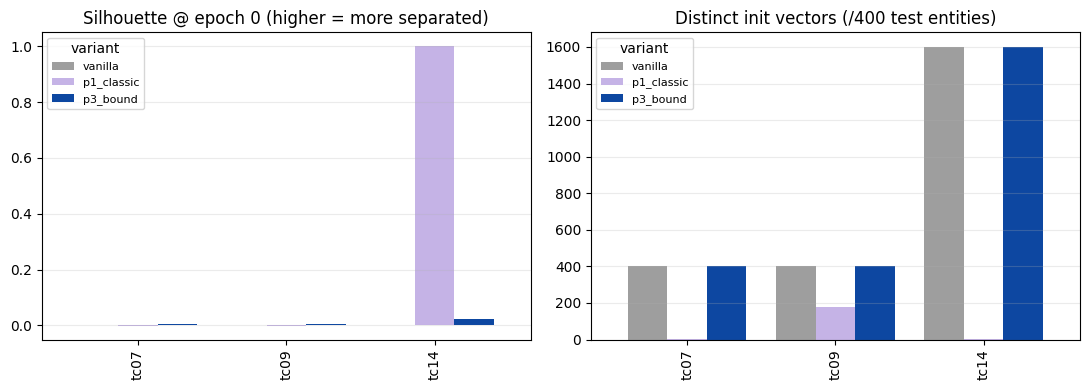

In [51]:
rows = []
for tc in SHOWCASE_TCS:
    for variant, _ in VARIANTS:
        run = EMB[tc][variant]
        x0, y = run["x0"], run["y"]
        rows.append(dict(
            tc=tc,
            variant=variant,
            acc_init=run["accs"][0],
            acc_final=run["accs"][-1],
            mean_cos_e0_e5=run["mean_cos"],
            distinct_init=run["n_distinct"],
            silhouette_init=silhouette_score(x0, y),
            results_json_final=RESULTS[tc][next(i for i, r in enumerate(RESULTS[tc]) if r["variant"] == variant)]["final_acc"],
        ))

summary = pd.DataFrame(rows)
display(summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in (
    (axes[0], "silhouette_init", "Silhouette @ epoch 0 (higher = more separated)"),
    (axes[1], "distinct_init", "Distinct init vectors (/400 test entities)"),
):
    pivot = summary.pivot(index="tc", columns="variant", values=metric)
    pivot = pivot[[v for v, _ in VARIANTS]]
    pivot.plot(kind="bar", ax=ax, color=[VARIANT_COLORS[v] for v, _ in VARIANTS], width=0.8)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(fontsize=8, title="variant")
    ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


## 7. LD1 margin — 1-D separability violin plots

Project onto the LDA axis and compare class distributions. A wide gap at epoch 0 means LogReg already has an easy job; overlapping violins explain chance-level accuracy.


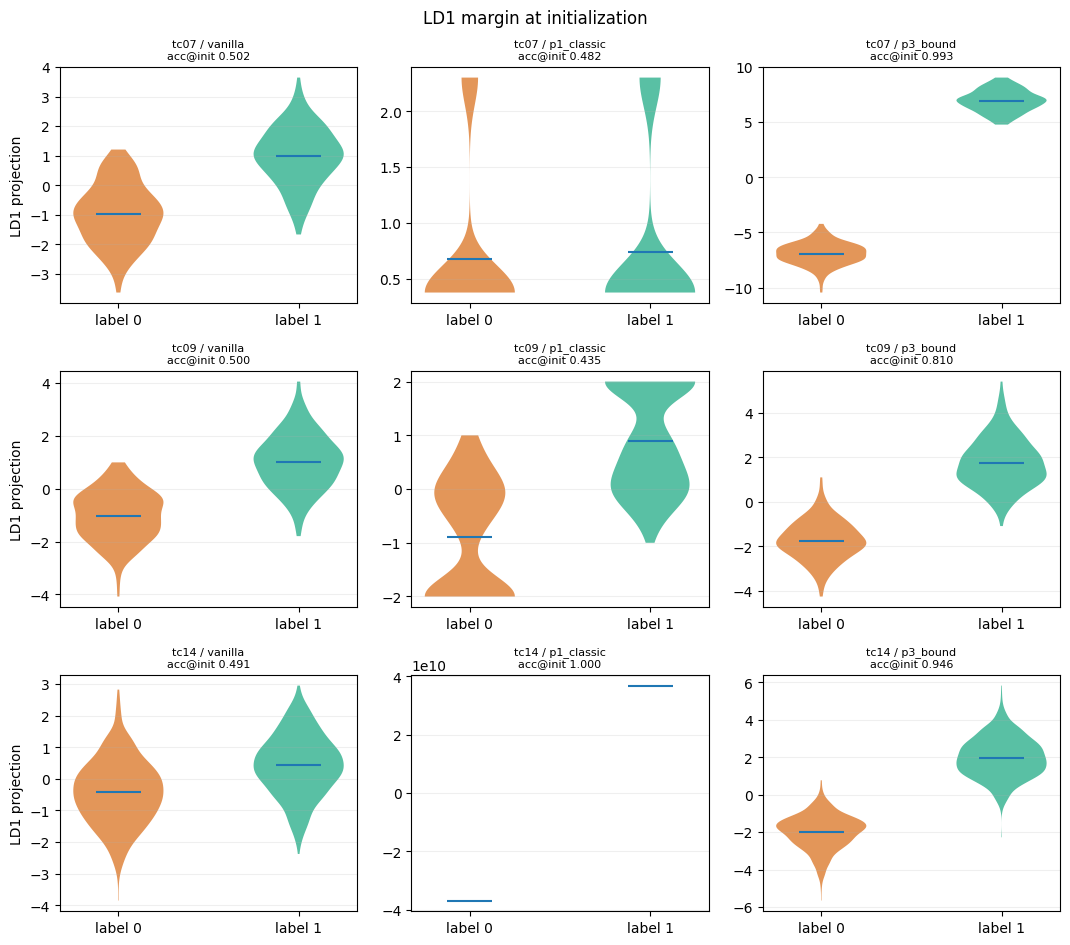

In [52]:
def ld1_projection(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    lda = LinearDiscriminantAnalysis(n_components=1, solver="svd")
    return lda.fit_transform(x, y).ravel()


fig, axes = plt.subplots(len(SHOWCASE_TCS), len(VARIANTS), figsize=(3.6 * len(VARIANTS), 3.2 * len(SHOWCASE_TCS)), sharex=False)
if len(SHOWCASE_TCS) == 1:
    axes = np.array([axes])
if len(VARIANTS) == 1:
    axes = axes[:, np.newaxis]

for i, tc in enumerate(SHOWCASE_TCS):
    for j, (variant, _) in enumerate(VARIANTS):
        run = EMB[tc][variant]
        z = ld1_projection(run["x0"], run["y"])
        data = [z[run["y"] == lab] for lab in (0, 1)]
        parts = axes[i, j].violinplot(data, positions=[0, 1], showmeans=True, showextrema=False)
        for body, lab in zip(parts["bodies"], (0, 1)):
            body.set_facecolor(LABEL_COLORS[lab])
            body.set_alpha(0.65)
        axes[i, j].set_xticks([0, 1], ["label 0", "label 1"])
        axes[i, j].set_title(f"{tc} / {variant}\nacc@init {run['accs'][0]:.3f}", fontsize=8)
        if j == 0:
            axes[i, j].set_ylabel("LD1 projection")
        axes[i, j].grid(True, axis="y", alpha=0.2)

fig.suptitle("LD1 margin at initialization", fontsize=12)
fig.tight_layout()
plt.show()


## Takeaways

1. **PCA can lie.** On relation-centric TCs the label boundary lives in low-variance directions; always pair PCA with LDA or margin plots when diagnosing classifiers on embeddings.
2. **`p1_classic` collapses** test entities onto class-mean points (see distinct-vector counts and t-SNE blobs) — useless when every labelled entity shares one class (tc07–tc12).
3. **`p3_bound` encodes the graph feature at init** — LDA / LD1 violins separate immediately; finetune barely moves vectors (`mean_cos ≈ 0.99`) which *preserves* the init rather than erasing it.
4. **Cardinality (tc09)** shows up as norm separation in `p3_bound` but not in `vanilla` / `p1_classic` — magnitude is part of the representation.
5. **tc14 is the sanity check** — own-class init works; all variants except vanilla achieve high silhouette. The visualization toolkit distinguishes *which kind of signal* each variant captures.


## 8. Accuracy & training curves across tc01–tc15 (all seven variants)

Same colour scheme and layout as `synthetic_compare.ipynb`, extended to **every** test case
tc01–tc15 and all seven variants (`vanilla`, `p1_classic`, `p2_classic`, `p3_classic`, `p1_bound`,
`p2_bound`, `p3_bound`).

`p3_classic` was run separately, so its accuracy is loaded from `notebooks/p3_classic/results.json`
(structured as `{tc: result}`) and merged into the curves built from `synthetic_compare/results.json`.

1. **Accuracy bar plot** — final-epoch LogReg test accuracy per TC (accuracy comes straight from `results.json`).
2. **Per-epoch accuracy** — the accuracy curves (epoch 0 = initialization) used as the stability check.
3. **Per-epoch loss** — gensim's summed SGNS training loss per finetune epoch. This is *not* stored in
   `results.json`, so the models are re-trained on the cached walk corpora (with `compute_loss=True`) and the
   curves are cached under `cache/loss_curves.json`. Loss magnitude is not comparable across variants
   (vanilla uses LR 0.025 vs the protected finetune LR 0.0025, and the bound inits start from large-norm
   vectors) — read the *shape*/trend per variant, not the absolute level.


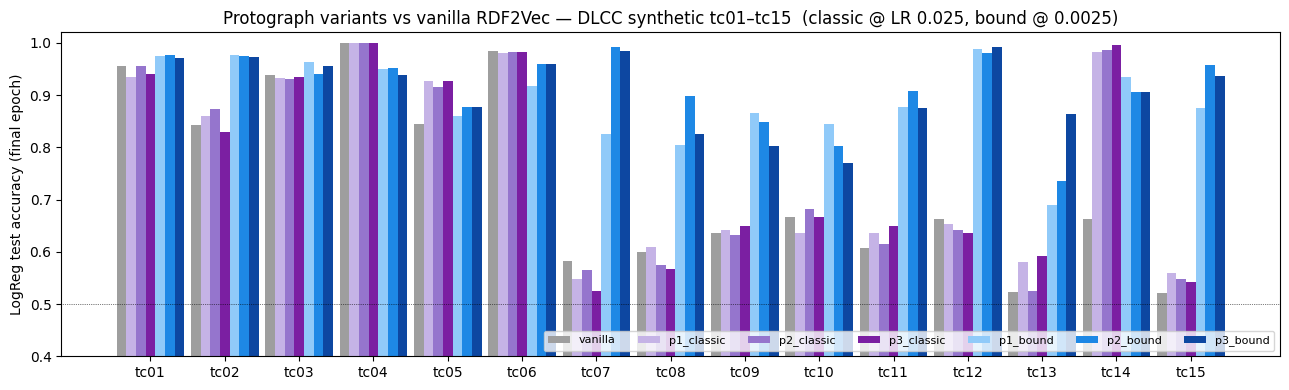

In [8]:
"""Accuracy bar plot — final-epoch LogReg test accuracy, tc01-tc15 (style: synthetic_compare.ipynb)."""
CURVE_TCS = [tc for tc in (f"tc{i:02d}" for i in range(1, 16)) if tc in RESULTS]

ALL_VARIANTS = ["vanilla", "p1_classic", "p2_classic", "p3_classic", "p1_bound", "p2_bound", "p3_bound"]
ALL_COLORS = {
    "vanilla": "#9e9e9e",
    "p1_classic": "#c5b3e6",
    "p2_classic": "#9575cd",
    "p3_classic": "#7b1fa2",
    "p1_bound": "#90caf9",
    "p2_bound": "#1e88e5",
    "p3_bound": "#0d47a1",
}

# accuracy curves straight from results.json: accs = [epoch0 (init), epoch1, ..., epoch5]
ACC = {tc: {r["variant"]: r["accs"] for r in RESULTS[tc]} for tc in CURVE_TCS}

# (classic variants are already at 0.025 here: RESULTS was patched from cache/classic_025_results.json
# in the setup cell, so ACC below includes p1/p2/p3_classic on the 0.025 recipe.)

# only plot variants that actually have curves for every showcase TC
PLOT_VARIANTS = [v for v in ALL_VARIANTS if all(v in ACC[tc] for tc in CURVE_TCS)]
missing = [v for v in ALL_VARIANTS if v not in PLOT_VARIANTS]
if missing:
    print("note: no accuracy curves for", ", ".join(missing), "- omitted from plots")

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(len(CURVE_TCS))
w = 0.13
center = (len(PLOT_VARIANTS) - 1) / 2
for i, v in enumerate(PLOT_VARIANTS):
    vals = [ACC[tc][v][-1] for tc in CURVE_TCS]
    ax.bar(x + (i - center) * w, vals, w, label=v, color=ALL_COLORS[v])
ax.set_xticks(x, CURVE_TCS)
ax.set_ylim(0.4, 1.02)
ax.axhline(0.5, color="k", lw=0.5, ls=":")
ax.set_ylabel("LogReg test accuracy (final epoch)")
ax.set_title("Protograph variants vs vanilla RDF2Vec — DLCC synthetic tc01–tc15  (classic @ LR 0.025, bound @ 0.0025)")
ax.legend(ncol=len(PLOT_VARIANTS), fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()


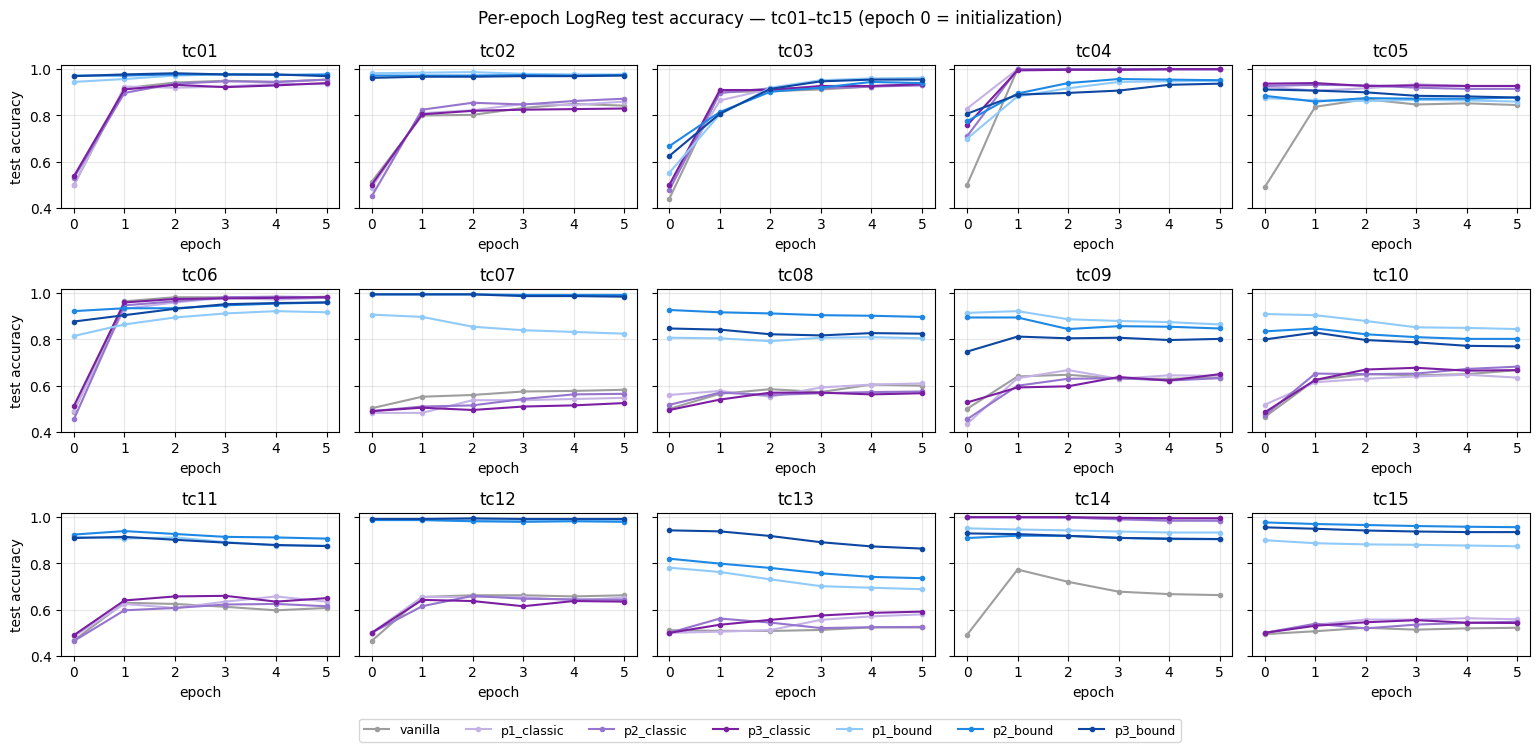

In [9]:
"""Per-epoch test accuracy, tc01-tc15 (epoch 0 = initialization; style: synthetic_compare.ipynb)."""
ncol = 5
nrow = int(np.ceil(len(CURVE_TCS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.5 * nrow), sharey=True)
axes = np.atleast_2d(axes)
for ax, tc in zip(axes.flat, CURVE_TCS):
    # iterate the merged ACC (includes p3_classic) so every available variant is drawn
    for v in PLOT_VARIANTS:
        accs = ACC[tc][v]
        ax.plot(range(len(accs)), accs, marker="o", ms=3,
                color=ALL_COLORS[v], label=v)
    ax.set_title(tc)
    ax.set_ylim(0.4, 1.02)
    ax.grid(alpha=0.3)
    ax.set_xlabel("epoch")
for ax in axes.flat[len(CURVE_TCS):]:
    ax.axis("off")
for r in range(nrow):
    axes[r, 0].set_ylabel("test accuracy")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(PLOT_VARIANTS), loc="lower center", fontsize=9)
fig.suptitle("Per-epoch LogReg test accuracy — tc01–tc15 (epoch 0 = initialization)")
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()


In [10]:
"""Per-epoch training loss: retrain each variant capturing gensim's SGNS loss (cached to loss_curves.json).

results.json stores only accuracy, so the loss curves are produced here by replaying the exact
synthetic_compare recipe (same cached walks, same init, same finetune LR) with compute_loss=True.
gensim's get_latest_training_loss() is cumulative within a train() call, so we diff per epoch.
"""
from gensim.models.callbacks import CallbackAny2Vec  # noqa: E402

LOSS_CACHE = CACHE_ROOT / "loss_curves.json"

# (variant, init mode, protograph) — mirrors run_tc() in synthetic_compare.ipynb.
# *_classic finetune at the from-scratch LR 0.025 (vanilla_alpha); only *_bound use the protected 0.0025.
CURVE_VARIANTS = [
    ("vanilla", "none", None),
    ("p1_classic", "classic", "p1"),
    ("p2_classic", "classic", "p2"),
    ("p3_classic", "classic", "p3"),
    ("p1_bound", "bound", "p1"),
    ("p2_bound", "bound", "p2"),
    ("p3_bound", "bound", "p3"),
]


class _LossPerEpoch(CallbackAny2Vec):
    """Record per-epoch loss by diffing gensim's cumulative training loss."""

    def __init__(self):
        self.losses: list[float] = []
        self._prev = 0.0

    def on_epoch_end(self, model):
        cum = model.get_latest_training_loss()
        self.losses.append(float(cum - self._prev))
        self._prev = cum


def capture_loss_curve(tc: str, init: str, proto: str | None) -> list[float]:
    sp = tc_paths(tc)
    inst_walks = sp["out"] / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt"
    alpha = CFG["finetune_alpha"] if init == "bound" else CFG["vanilla_alpha"]

    model = new_skipgram_model(
        dim=CFG["dim"], alpha=alpha, min_alpha=CFG["min_alpha"], seed=CFG["seed"], workers=16
    )
    model.compute_loss = True
    model.build_vocab(LineSentence(str(inst_walks)))
    if init != "none":
        stage1, used_norm = _stage1(sp["out"] / f"walks_{proto}.txt")
        bound = None
        if init == "bound":
            bound = concept_bound_vectors(sp["graph"], sp["ontology"], stage1, target_norm=used_norm)
        protograph_init(
            model, stage1, sp["ontology"], strategy="all_init",
            target_norm=used_norm, bound_vectors=bound,
        )
    cb = _LossPerEpoch()
    model.train(
        corpus_iterable=LineSentence(str(inst_walks)),
        total_examples=model.corpus_count, epochs=CFG["epochs"],
        start_alpha=alpha, end_alpha=CFG["min_alpha"],
        compute_loss=True, callbacks=[cb],
    )
    return cb.losses


def load_or_compute_losses(*, force: bool = False) -> dict[str, dict[str, list[float]]]:
    cache = {} if force or not LOSS_CACHE.is_file() else json.loads(LOSS_CACHE.read_text())
    for tc in CURVE_TCS:
        cache.setdefault(tc, {})
        for name, init, proto in CURVE_VARIANTS:
            if name in cache[tc]:
                continue
            print(f"  loss {tc} / {name} ...", flush=True)
            cache[tc][name] = capture_loss_curve(tc, init, proto)
            LOSS_CACHE.write_text(json.dumps(cache, indent=2))
    return cache


LOSS = load_or_compute_losses()
print("loss curves ready:", ", ".join(LOSS))


loss curves ready: tc01, tc02, tc03, tc04, tc05, tc06, tc07, tc08, tc09, tc10, tc11, tc12, tc13, tc14, tc15


In [1]:
"""Per-epoch training loss, tc01-tc15 — normalized to each curve's epoch-1 loss.

Raw summed SGNS loss is in the millions and scales with corpus size (per TC) and
learning rate (0.025 for vanilla/*_classic vs 0.0025 for *_bound), so the absolute
level is not comparable. Dividing each curve by its own epoch-1 loss puts every
variant on a shared dimensionless axis (epoch 1 = 1.0), so the decay *shape* is the
message. p1_classic's degenerate own-class init gives it an anomalously low epoch-1
loss, so on some TCs it runs off the top of the capped axis (marked with ^)."""
ASSET_DIR = ROOT / "latex" / "assets" / "compare"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
YMAX = 1.4  # 6/7 variants live in [0.35, 1.25]; only the unstable p1_classic spikes above

ncol = 5
nrow = int(np.ceil(len(CURVE_TCS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.5 * nrow), sharey=True)
axes = np.atleast_2d(axes)
for ax, tc in zip(axes.flat, CURVE_TCS):
    for v in PLOT_VARIANTS:
        losses = LOSS.get(tc, {}).get(v)
        if not losses or not losses[0]:
            continue
        rel = np.asarray(losses, dtype=float) / losses[0]  # epoch 1 = 1.0
        ep = np.arange(1, len(rel) + 1)
        ax.plot(ep, np.minimum(rel, YMAX), marker="o", ms=3, color=ALL_COLORS[v], label=v)
        clipped = rel > YMAX  # mark off-scale points so a clipped curve isn't hidden silently
        if clipped.any():
            ax.plot(ep[clipped], np.full(int(clipped.sum()), YMAX), marker="^", ms=5,
                    ls="none", color=ALL_COLORS[v])
    ax.set_title(tc)
    ax.grid(alpha=0.3)
    ax.set_xlabel("epoch")
    ax.set_xticks(range(1, CFG["epochs"] + 1))
    ax.axhline(1.0, color="k", lw=0.5, ls=":")
axes.flat[0].set_ylim(0.3, YMAX + 0.02)  # sharey -> propagates to every panel
for ax in axes.flat[len(CURVE_TCS):]:
    ax.axis("off")
for r in range(nrow):
    axes[r, 0].set_ylabel("training loss (epoch 1 = 1.0)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(PLOT_VARIANTS), loc="lower center", fontsize=9)
fig.suptitle("Per-epoch SGNS training loss, normalized to epoch 1 — tc01–tc15 "
             "(^ = curve clipped above the cap)")
fig.tight_layout(rect=(0, 0.04, 1, 1))
fig.savefig(ASSET_DIR / "epoch_loss_tc01_tc15.png", dpi=150)
plt.show()

NameError: name 'ROOT' is not defined

## 9. Mean accuracy per epoch, averaged over tc01–tc15

One curve per variant: the per-epoch LogReg test accuracy (epoch 0 = initialization) **averaged across all
15 test cases**. Same recipe as Section 8 — `*_classic` finetuned at LR 0.025, `*_bound` at the protected
0.0025 — so the gaps here summarise, in a single panel, what the per-TC grids show case by case.

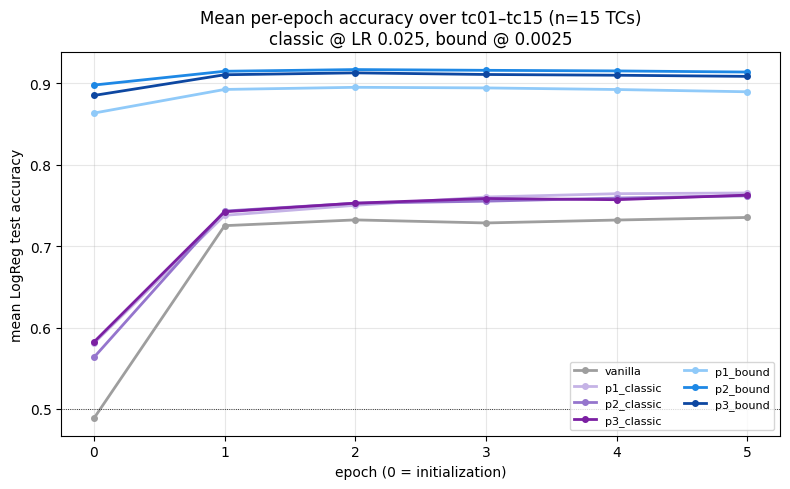

,init (e0),final (e5)
vanilla,0.4885,0.7352
p1_classic,0.5807,0.7653
p2_classic,0.5633,0.7618
p3_classic,0.5822,0.7627
p1_bound,0.8635,0.8896
p2_bound,0.8979,0.9139
p3_bound,0.8851,0.9085


In [12]:
"""Mean per-epoch test accuracy averaged over all of tc01–tc15 (one line per variant)."""
EPOCHS = list(range(6))  # 0 = initialization, 1..5 = finetune epochs

fig, ax = plt.subplots(figsize=(8, 5))
mean_at = {}
for v in PLOT_VARIANTS:
    M = np.array([ACC[tc][v] for tc in CURVE_TCS])  # (n_tc, 6)
    mean = M.mean(axis=0)
    mean_at[v] = mean
    ax.plot(EPOCHS, mean, marker="o", ms=4, lw=2, color=ALL_COLORS[v], label=v)

ax.axhline(0.5, color="k", lw=0.6, ls=":")
ax.set_xticks(EPOCHS)
ax.set_xlabel("epoch (0 = initialization)")
ax.set_ylabel("mean LogReg test accuracy")
ax.set_title(f"Mean per-epoch accuracy over tc01\u2013tc15 (n={len(CURVE_TCS)} TCs)\n"
             "classic @ LR 0.025, bound @ 0.0025")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

mean_summary = pd.DataFrame(
    {"init (e0)": {v: mean_at[v][0] for v in PLOT_VARIANTS},
     "final (e5)": {v: mean_at[v][-1] for v in PLOT_VARIANTS}}
).round(4)
display(mean_summary)

## 10. PCA grid — all seven methods for one TC

Side-by-side PCA of the **test entities at initialization (epoch 0)** for every method:
`vanilla` + (`p1`/`p2`/`p3`) × (`classic`/`bound`). Coloured by label. Unlike the cached
`EMB` (only 3 showcase variants), this computes all seven inits on demand for a single TC
(`GRID_TC`) — init-only, so no finetuning is needed and it stays fast. Same recipe and walk
corpora as the rest of the notebook (`classic` = MASCHInE class-mean init, `bound` = concept-bound
init). PCA shows max-variance directions, so a mixed look here doesn't imply non-separability —
cross-check with the LDA / LD1 panels above.

KeyboardInterrupt: 

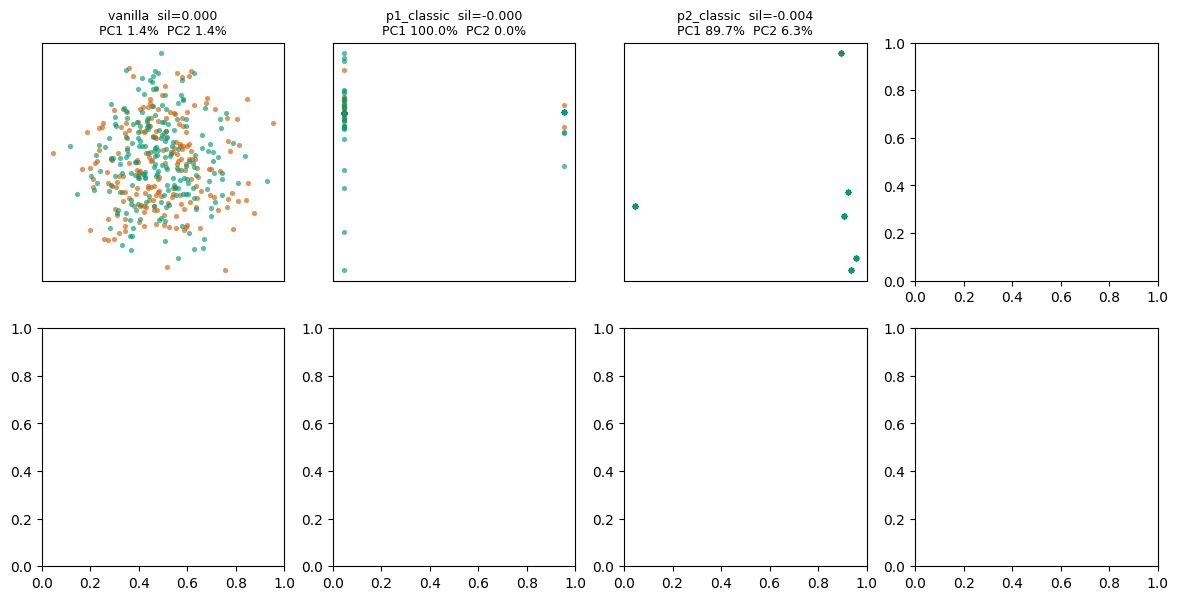

In [13]:
"""PCA grid for one TC across all seven methods (vanilla + p1/p2/p3 × classic/bound).

Computes test-entity embeddings at initialization (epoch 0) for every method — init-only, so no
finetuning is required. Reuses the cached protograph stage-1 vectors (`_stage1`) and walk corpora.
"""
GRID_TC = "tc07"  # pick any tc with walks under notebooks/synthetic_compare/<tc>/

# (label, init mode, protograph) — mirrors CURVE_VARIANTS / ALL_VARIANTS above
GRID_VARIANTS = [
    ("vanilla", "none", "p1"),
    ("p1_classic", "classic", "p1"),
    ("p2_classic", "classic", "p2"),
    ("p3_classic", "classic", "p3"),
    ("p1_bound", "bound", "p1"),
    ("p2_bound", "bound", "p2"),
    ("p3_bound", "bound", "p3"),
]


def init_test_embeddings(tc: str, init: str, proto: str) -> tuple[np.ndarray, np.ndarray]:
    """Test-entity embeddings at epoch 0 (initialization only — no finetuning)."""
    sp = tc_paths(tc)
    inst_walks = sp["out"] / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt"
    proto_walks = sp["out"] / f"walks_{proto}.txt"
    if not inst_walks.is_file():
        raise FileNotFoundError(f"Missing instance walks for {tc}; run synthetic_compare first")

    model = new_skipgram_model(
        dim=CFG["dim"], alpha=CFG["vanilla_alpha"], min_alpha=CFG["min_alpha"],
        seed=CFG["seed"], workers=16,
    )
    model.build_vocab(LineSentence(str(inst_walks)))
    if init != "none":
        stage1, used_norm = _stage1(proto_walks)
        bound = None
        if init == "bound":
            bound = concept_bound_vectors(sp["graph"], sp["ontology"], stage1, target_norm=used_norm)
        protograph_init(
            model, stage1, sp["ontology"], strategy="all_init",
            target_norm=used_norm, bound_vectors=bound,
        )

    test_tokens, y_test = load_labeled_txt(sp["test"])
    emb = np.asarray(model.wv.vectors, dtype=np.float32)
    w2i = dict(model.wv.key_to_index)
    x0, _oov = tokens_to_embeddings(test_tokens, emb, w2i, "", 4096, progress=False)
    return x0, y_test


def plot_pca_grid(tc: str, ncol: int = 4):
    nrow = int(np.ceil(len(GRID_VARIANTS) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 3.4 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, (variant, init, proto) in zip(axes, GRID_VARIANTS):
        x, y = init_test_embeddings(tc, init, proto)
        pca = PCA(n_components=2, random_state=CFG["seed"])
        xy = pca.fit_transform(x)
        sil = silhouette_score(x, y) if len(np.unique(y)) > 1 else float("nan")
        ev = pca.explained_variance_ratio_ * 100
        scatter_labels(
            ax, xy, y,
            title=f"{variant}  sil={sil:.3f}\nPC1 {ev[0]:.1f}%  PC2 {ev[1]:.1f}%",
        )
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(GRID_VARIANTS):]:
        ax.axis("off")
    axes[0].legend(fontsize=7, loc="best")
    fig.suptitle(f"{tc}: PCA of test entities at initialization — all seven methods", fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


plot_pca_grid(GRID_TC)

## 11. Cosine drift per epoch — tc01–tc14 (all seven methods)

How far the **test-entity embeddings rotate away from their initialization** as finetuning
proceeds. For each method and TC we snapshot the test-entity vectors at epoch 0 (initialization)
and after every finetune epoch, then measure the *cosine drift*

$$d_i \;=\; \operatorname{mean}_e\bigl(1 - |\cos(x_e^{(0)},\, x_e^{(i)})|\bigr)$$

— the mean over test entities of `1 - |cosine similarity|` between epoch 0 and epoch *i* (so
`d_0 = 0` by construction; the absolute value treats a sign flip as no drift). Small drift means
the init geometry is preserved (desirable for the `*_bound` inits at the protected LR 0.0025);
large drift means the vectors are being overwritten — for `vanilla` / `*_classic` at LR 0.025 the
random / class-mean init carries little signal, so heavy drift is expected and harmless.

Like the loss curves in Section 8 this is not stored in `results.json`, so the models are re-trained
on the cached walk corpora (same recipe: `*_classic` @ LR 0.025, `*_bound` @ 0.0025) and the drift
curves are cached under `cache/cosine_drift.json`.

In [14]:
"""Per-epoch cosine drift: snapshot test-entity vectors each epoch, diff vs epoch 0 (cached).

Mirrors the loss-curve recipe in Section 8 — same cached walks, same init, same finetune LR — but
records, per epoch, the mean over test entities of (1 - |cos(x0, x_epoch)|). A fixed vocabulary
means key_to_index is stable across epochs, so the epoch-0 embedding x0 is captured once and reused.
"""
DRIFT_CACHE = CACHE_ROOT / "cosine_drift.json"
DRIFT_TCS = [f"tc{i:02d}" for i in range(1, 15) if f"tc{i:02d}" in RESULTS]  # tc01-tc14


def _mean_cos_drift(x0: np.ndarray, xi: np.ndarray) -> float:
    """mean_e (1 - |cos(x0_e, xi_e)|) over rows with non-zero norm at both epochs."""
    n0, ni = np.linalg.norm(x0, axis=1), np.linalg.norm(xi, axis=1)
    ok = (n0 > 0) & (ni > 0)
    if not ok.any():
        return float("nan")
    cos = (x0[ok] * xi[ok]).sum(1) / (n0[ok] * ni[ok])
    return float((1.0 - np.abs(cos)).mean())


class _DriftPerEpoch(CallbackAny2Vec):
    """Record the cosine drift of test entities vs their epoch-0 vectors."""

    def __init__(self, test_tokens: list[str], w2i: dict[str, int], x0: np.ndarray):
        self.test_tokens = test_tokens
        self.w2i = w2i
        self.x0 = x0
        self.drifts: list[float] = []

    def on_epoch_end(self, model):
        emb = np.asarray(model.wv.vectors, dtype=np.float32)
        xi, _ = tokens_to_embeddings(self.test_tokens, emb, self.w2i, "", 4096, progress=False)
        self.drifts.append(_mean_cos_drift(self.x0, xi))


def capture_drift_curve(tc: str, init: str, proto: str | None) -> list[float]:
    """[0.0, drift@e1, ..., drift@eN] for one variant (epoch 0 drift is 0 by definition)."""
    sp = tc_paths(tc)
    inst_walks = sp["out"] / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt"
    alpha = CFG["finetune_alpha"] if init == "bound" else CFG["vanilla_alpha"]

    model = new_skipgram_model(
        dim=CFG["dim"], alpha=alpha, min_alpha=CFG["min_alpha"], seed=CFG["seed"], workers=16
    )
    model.build_vocab(LineSentence(str(inst_walks)))
    if init != "none":
        stage1, used_norm = _stage1(sp["out"] / f"walks_{proto}.txt")
        bound = None
        if init == "bound":
            bound = concept_bound_vectors(sp["graph"], sp["ontology"], stage1, target_norm=used_norm)
        protograph_init(
            model, stage1, sp["ontology"], strategy="all_init",
            target_norm=used_norm, bound_vectors=bound,
        )

    test_tokens, _y = load_labeled_txt(sp["test"])
    emb = np.asarray(model.wv.vectors, dtype=np.float32)
    w2i = dict(model.wv.key_to_index)
    x0, _oov = tokens_to_embeddings(test_tokens, emb, w2i, "", 4096, progress=False)

    cb = _DriftPerEpoch(test_tokens, w2i, x0)
    model.train(
        corpus_iterable=LineSentence(str(inst_walks)),
        total_examples=model.corpus_count, epochs=CFG["epochs"],
        start_alpha=alpha, end_alpha=CFG["min_alpha"], callbacks=[cb],
    )
    return [0.0] + cb.drifts


def load_or_compute_drift(*, force: bool = False) -> dict[str, dict[str, list[float]]]:
    cache = {} if force or not DRIFT_CACHE.is_file() else json.loads(DRIFT_CACHE.read_text())
    for tc in DRIFT_TCS:
        cache.setdefault(tc, {})
        for name, init, proto in CURVE_VARIANTS:
            if name in cache[tc]:
                continue
            print(f"  drift {tc} / {name} ...", flush=True)
            cache[tc][name] = capture_drift_curve(tc, init, proto)
            DRIFT_CACHE.write_text(json.dumps(cache, indent=2))
    return cache


DRIFT = load_or_compute_drift()
print("drift curves ready:", ", ".join(DRIFT_TCS))


# --- grid: one panel per TC, one line per method ---------------------------
ncol = 5
nrow = int(np.ceil(len(DRIFT_TCS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.1 * ncol, 2.5 * nrow), sharey=True)
axes = np.atleast_2d(axes)
for ax, tc in zip(axes.flat, DRIFT_TCS):
    for v in PLOT_VARIANTS:
        curve = DRIFT.get(tc, {}).get(v)
        if not curve:
            continue
        ax.plot(range(len(curve)), curve, marker="o", ms=3, color=ALL_COLORS[v], label=v)
    ax.set_title(tc)
    ax.grid(alpha=0.3)
    ax.set_xlabel("epoch")
    ax.set_xticks(range(CFG["epochs"] + 1))
for ax in axes.flat[len(DRIFT_TCS):]:
    ax.axis("off")
for r in range(nrow):
    axes[r, 0].set_ylabel("1 - |cos(e0, eᵢ)|")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(PLOT_VARIANTS), loc="lower center", fontsize=9)
fig.suptitle("Cosine drift from initialization — tc01–tc14 (mean over test entities, vs epoch 0)")
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

  drift tc01 / vanilla ...
  drift tc01 / p1_classic ...
  drift tc01 / p2_classic ...
  drift tc01 / p3_classic ...
  drift tc01 / p1_bound ...
  drift tc01 / p2_bound ...
  drift tc01 / p3_bound ...
  drift tc02 / vanilla ...
  drift tc02 / p1_classic ...
  drift tc02 / p2_classic ...
  drift tc02 / p3_classic ...
  drift tc02 / p1_bound ...
  drift tc02 / p2_bound ...
  drift tc02 / p3_bound ...
  drift tc03 / vanilla ...
  drift tc03 / p1_classic ...


KeyboardInterrupt: 